# 03 · Results for the paper

- **A.** SmolLM2 baseline (CausalCoT run on the easy file), rescored with the tolerant yes/no parser.
- **B.** Commonsense-alignment results from notebook 02: accuracy by variant (H1), P(Yes) shift on matched pairs (H1b), accuracy by rung (H2), answer bias, topology, failure graphs.
- **C.** Export: LaTeX table rows and PDF figures into the paper folder.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causal_evaluation.evaluation.failure_graph import draw_failure_graph, failure_graph
from causal_evaluation.evaluation.stats import extract_yes_no
from causal_evaluation.evaluation.variant_analysis import (
    load_scored,
    nonsense_gap,
    p_yes_shift,
    paired_accuracy_gap,
    rate_table,
)

INTERIM = Path(os.environ.get("CE_INTERIM", ROOT / "data" / "interim"))
PAPER_DIR = Path(os.environ.get("CE_PAPER_DIR", ROOT.parent / "tesispp" / "cadis-extended-abstract"))
FIG_DIR, TAB_DIR = PAPER_DIR / "figures", PAPER_DIR / "tables"
for folder in (FIG_DIR, TAB_DIR):
    folder.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 3)


def short(model):
    return model.split("/")[-1].split(":")[0]

## A · SmolLM2 baseline, rescored

In [2]:
sample_full = pd.read_json(INTERIM / "sample-full.jsonl", lines=True, dtype={"question_id": str})
responses = pd.read_json(INTERIM / "responses-smollm2-full.jsonl", lines=True, dtype={"question_id": str})
responses["text"] = responses["response"].map(lambda r: r.get("text") or "")
responses["error"] = responses["response"].map(lambda r: r.get("error"))

base = responses.merge(
    sample_full[["question_id", "answer", "causal_level", "meta"]], on="question_id", validate="one_to_one"
)
base["answer"] = base["answer"].str.strip().str.lower()
base["story_kind"] = base["meta"].map(lambda m: "nonsense" if str(m["story_id"]).startswith("nonsense") else "named")
base["parsed"] = base["text"].map(extract_yes_no)
base["status"] = np.select([base["error"].notna(), base["parsed"].isna()], ["error", "unparsed"], "parsed")
base["correct_exact"] = base["text"].str.strip().str.casefold() == base["answer"]
base["correct_parsed"] = base["parsed"] == base["answer"]
base["is_yes"] = base["parsed"] == "yes"

base["status"].value_counts()

status
parsed      10105
error         347
unparsed      108
Name: count, dtype: int64

In [3]:
baseline = pd.DataFrame(
    {
        "exact_match": base.groupby("causal_level")["correct_exact"].mean(),
        "tolerant_parser": base.groupby("causal_level")["correct_parsed"].mean(),
        "n": base.groupby("causal_level").size(),
    }
)
baseline.loc["overall"] = [base["correct_exact"].mean(), base["correct_parsed"].mean(), len(base)]
baseline

,exact_match,tolerant_parser,n
causal_level,,,
1,0.453,0.467,3288.0
2,0.461,0.485,3288.0
3,0.449,0.468,3984.0
overall,0.454,0.473,10560.0


In [4]:
parsed = base[base["status"] == "parsed"]
display(rate_table(parsed, ["causal_level"], flag="correct_parsed"))
display(rate_table(parsed, ["story_kind"], flag="correct_parsed"))
print(f"Yes rate among parsed answers: {parsed['is_yes'].mean():.3f} (answers are 50/50)")

,causal_level,n,k,rate,lo,hi
0,1,3172,1537,0.485,0.467,0.502
1,2,3126,1595,0.510,0.493,0.528
2,3,3807,1863,0.489,0.474,0.505


,story_kind,n,k,rate,lo,hi
0,named,2747,1298,0.473,0.454,0.491
1,nonsense,7358,3697,0.502,0.491,0.514


Yes rate among parsed answers: 0.640 (answers are 50/50)


## B · Commonsense alignment

In [5]:
USE_SMOKE = False  # True only to test this notebook with the -smoke files from notebook 02
result_paths = [p for p in sorted(INTERIM.glob("logprobs-*.jsonl")) if p.name.endswith("-smoke.jsonl") == USE_SMOKE]
print("\n".join(p.name for p in result_paths))
df = load_scored(INTERIM / "variants-sample.jsonl", result_paths)
df["is_yes"] = df["pred"] == "yes"
df.groupby("model").agg(
    items=("item_id", "size"),
    median_answer_mass=("answer_mass", "median"),
    yes_rate=("is_yes", "mean"),
)

logprobs-Phi-3.5-mini-instruct.jsonl
logprobs-Qwen2.5-1.5B-Instruct.jsonl
logprobs-Qwen2.5-7B-Instruct.jsonl
logprobs-SmolLM2-1.7B-Instruct.jsonl


,items,median_answer_mass,yes_rate
model,,,
HuggingFaceTB/SmolLM2-1.7B-Instruct,3000,0.991,6.667e-04
Qwen/Qwen2.5-1.5B-Instruct,3000,1.000,4.973e-01
Qwen/Qwen2.5-7B-Instruct,3000,1.000,4.790e-01
microsoft/Phi-3.5-mini-instruct,3000,1.000,3.273e-01


### Accuracy by variant

In [6]:
acc = rate_table(df, ["model", "variant"])
acc.pivot(index="model", columns="variant", values="rate")

variant,anticommonsense,commonsense,noncommonsense
model,,,
HuggingFaceTB/SmolLM2-1.7B-Instruct,0.500,0.502,0.500
Qwen/Qwen2.5-1.5B-Instruct,0.501,0.515,0.534
Qwen/Qwen2.5-7B-Instruct,0.596,0.571,0.556
microsoft/Phi-3.5-mini-instruct,0.572,0.586,0.552


### H1 · Anticommonsense gap on matched pairs, and nonsense gap

In [7]:
h1_paired = paired_accuracy_gap(df)
h1_paired

,model,pairs,acc_common,acc_anti,gap,gap_lo,gap_hi,only_common_correct,only_anti_correct,mcnemar_p
0,HuggingFaceTB/SmolLM2-1.7B-Instruct,1000,0.502,0.500,0.002,0.000,0.005,2,0,0.500
1,Qwen/Qwen2.5-1.5B-Instruct,1000,0.515,0.501,0.014,-0.013,0.042,109,95,0.363
2,Qwen/Qwen2.5-7B-Instruct,1000,0.571,0.596,-0.025,-0.055,0.005,107,132,0.120
3,microsoft/Phi-3.5-mini-instruct,1000,0.586,0.572,0.014,-0.014,0.042,111,97,0.367


In [8]:
h1_nonsense = nonsense_gap(df)
h1_nonsense

,model,acc_common,acc_nonsense,gap,gap_lo,gap_hi
0,HuggingFaceTB/SmolLM2-1.7B-Instruct,0.502,0.500,0.002,-0.042,0.046
1,Qwen/Qwen2.5-1.5B-Instruct,0.515,0.534,-0.019,-0.063,0.025
2,Qwen/Qwen2.5-7B-Instruct,0.571,0.556,0.015,-0.028,0.058
3,microsoft/Phi-3.5-mini-instruct,0.586,0.552,0.034,-0.009,0.077


### H1b · P(Yes) shift on matched relational items (commonsense minus anticommonsense)

In [9]:
h1b = p_yes_shift(df)
h1b

,model,answer,pairs,p_yes_common,p_yes_anti,shift,shift_lo,shift_hi
0,HuggingFaceTB/SmolLM2-1.7B-Instruct,no,328,0.217,0.209,0.008,0.002,0.015
1,HuggingFaceTB/SmolLM2-1.7B-Instruct,yes,330,0.227,0.223,0.004,-0.002,0.010
2,Qwen/Qwen2.5-1.5B-Instruct,no,328,0.461,0.504,-0.043,-0.069,-0.016
3,Qwen/Qwen2.5-1.5B-Instruct,yes,330,0.550,0.594,-0.044,-0.063,-0.026
4,Qwen/Qwen2.5-7B-Instruct,no,328,0.406,0.411,-0.005,-0.057,0.046
5,Qwen/Qwen2.5-7B-Instruct,yes,330,0.639,0.689,-0.050,-0.093,-0.007
6,microsoft/Phi-3.5-mini-instruct,no,328,0.326,0.276,0.050,0.001,0.098
7,microsoft/Phi-3.5-mini-instruct,yes,330,0.593,0.540,0.053,0.004,0.103


### H2 · Accuracy by rung

In [10]:
h2 = rate_table(df, ["model", "rung"])
h2.pivot(index="model", columns="rung", values="rate")

rung,1,2,3
model,,,
HuggingFaceTB/SmolLM2-1.7B-Instruct,0.500,0.502,0.500
Qwen/Qwen2.5-1.5B-Instruct,0.493,0.495,0.562
Qwen/Qwen2.5-7B-Instruct,0.522,0.636,0.565
microsoft/Phi-3.5-mini-instruct,0.537,0.582,0.591


### Answer bias and topology

In [11]:
yes_rates = rate_table(df, ["model", "variant"], flag="is_yes")
display(yes_rates.pivot(index="model", columns="variant", values="rate"))
rate_table(df, ["model", "graph_id"]).pivot(index="graph_id", columns="model", values="rate")

variant,anticommonsense,commonsense,noncommonsense
model,,,
HuggingFaceTB/SmolLM2-1.7B-Instruct,0.000,0.002,0.000
Qwen/Qwen2.5-1.5B-Instruct,0.525,0.493,0.474
Qwen/Qwen2.5-7B-Instruct,0.474,0.449,0.514
microsoft/Phi-3.5-mini-instruct,0.306,0.342,0.334


model,HuggingFaceTB/SmolLM2-1.7B-Instruct,Qwen/Qwen2.5-1.5B-Instruct,Qwen/Qwen2.5-7B-Instruct,microsoft/Phi-3.5-mini-instruct
graph_id,,,,
IV,0.493,0.532,0.479,0.514
arrowhead,0.541,0.530,0.589,0.600
chain,0.526,0.596,0.645,0.566
collision,0.457,0.330,0.439,0.457
confounding,0.498,0.518,0.583,0.648
diamond,0.474,0.551,0.610,0.582
diamondcut,0.469,0.517,0.510,0.559
fork,0.533,0.553,0.586,0.616
frontdoor,0.613,0.560,0.601,0.649


## C · Figures and table for the paper

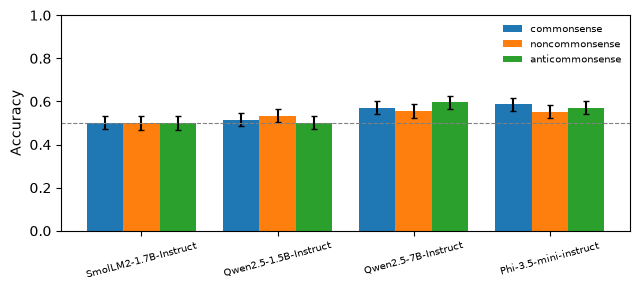

In [12]:
order = ["commonsense", "noncommonsense", "anticommonsense"]
models = sorted(df["model"].unique())
fig, ax = plt.subplots(figsize=(6.5, 3))
width = 0.8 / len(order)
for i, variant in enumerate(order):
    rows = acc[acc["variant"] == variant].set_index("model").reindex(models)
    x = np.arange(len(models)) + (i - 1) * width
    ax.bar(x, rows["rate"], width, label=variant,
           yerr=[rows["rate"] - rows["lo"], rows["hi"] - rows["rate"]], capsize=2)
ax.axhline(0.5, color="gray", lw=0.8, ls="--")
ax.set_xticks(np.arange(len(models)), [short(m) for m in models], rotation=15, fontsize=7)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_by_variant.pdf")

,source,target,lift,pairs
13,"(3, ett)","(3, nde)",1.077,596
2,"(1, correlation)","(3, nde)",1.076,825
10,"(2, backadj)","(3, det-counterfactual)",1.046,773
7,"(2, ate)","(3, ett)",1.038,1491
3,"(1, marginal)","(2, ate)",1.037,1970
11,"(2, backadj)","(3, ett)",1.036,923
6,"(1, marginal)","(3, nde)",1.036,734
16,"(1, marginal)","(2, collider_bias)",1.030,287


,source,target,lift,pairs
17,"(1, exp_away)","(1, marginal)",1.105,177
0,"(1, correlation)","(1, marginal)",1.098,1548
7,"(1, marginal)","(3, nde)",1.075,734
14,"(3, det-counterfactual)","(3, ett)",1.062,687
4,"(1, correlation)","(3, nde)",1.061,825
1,"(1, correlation)","(2, backadj)",1.047,1237
18,"(1, exp_away)","(2, backadj)",1.047,163
10,"(2, ate)","(3, nde)",1.041,924


,source,target,lift,pairs
11,"(2, ate)","(3, nie)",1.275,823
6,"(1, marginal)","(3, nde)",1.191,734
3,"(1, correlation)","(3, nie)",1.175,819
13,"(2, backadj)","(3, ett)",1.084,923
2,"(1, correlation)","(3, ett)",1.071,1291
8,"(2, ate)","(2, backadj)",1.067,1498
7,"(1, marginal)","(3, nie)",1.065,742
5,"(1, marginal)","(3, det-counterfactual)",1.059,940


,source,target,lift,pairs
5,"(2, ate)","(3, nde)",1.157,924
4,"(2, ate)","(3, ett)",1.147,1491
1,"(1, correlation)","(3, nie)",1.142,819
9,"(1, exp_away)","(1, marginal)",1.120,177
8,"(3, nde)","(3, nie)",1.072,540
2,"(1, marginal)","(2, backadj)",1.056,1384
10,"(1, exp_away)","(2, backadj)",1.046,163
6,"(2, backadj)","(3, ett)",1.041,923


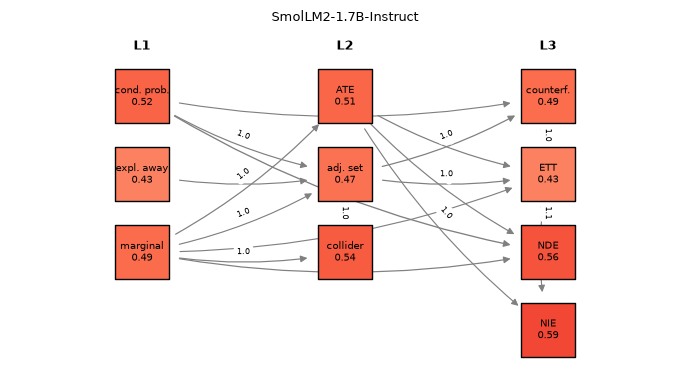

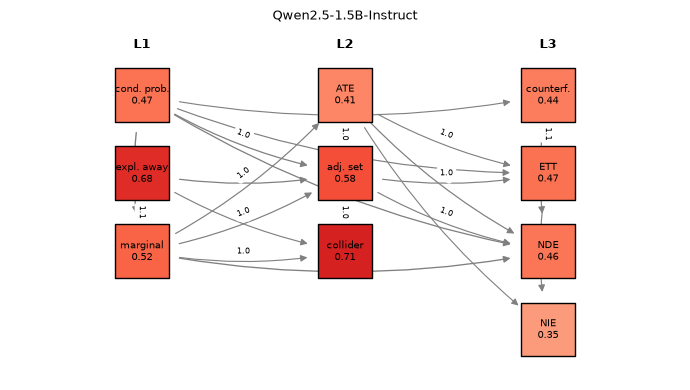

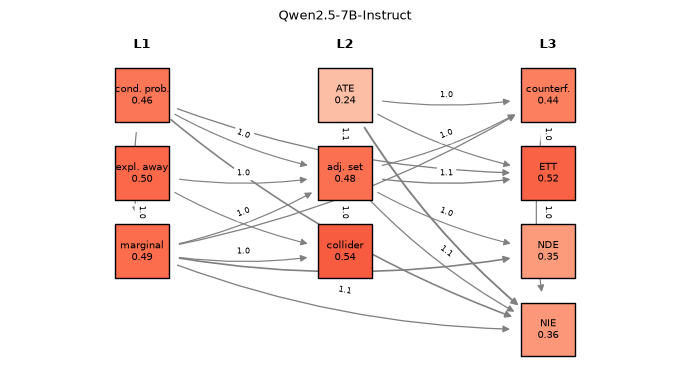

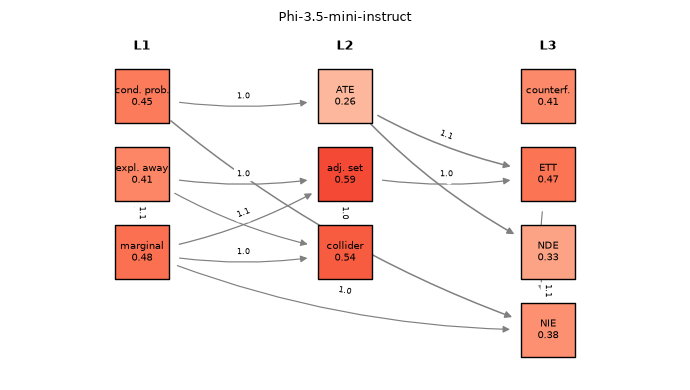

In [13]:
for model in models:
    nodes, edges = failure_graph(df[df["model"] == model])
    fig, ax = plt.subplots(figsize=(7, 4))
    draw_failure_graph(nodes, edges, ax=ax, title=short(model))
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"failure_graph_{short(model)}.pdf")
    display(edges.sort_values("lift", ascending=False).head(8))

In [14]:
def cell(row):
    return f"{row.rate:.2f} [{row.lo:.2f}, {row.hi:.2f}]"


shift_yes = h1b[h1b["answer"] == "yes"].set_index("model")
lines = []
for model in models:
    cells = {r.variant: cell(r) for r in acc[acc["model"] == model].itertuples()}
    p_yes = (
        f"{shift_yes.loc[model, 'p_yes_common']:.2f} / {shift_yes.loc[model, 'p_yes_anti']:.2f}"
        if model in shift_yes.index
        else "--"
    )
    name = short(model).replace("_", r"\_")
    lines.append(
        f"{name} & {cells.get('commonsense', '--')} & {cells.get('noncommonsense', '--')} & "
        f"{cells.get('anticommonsense', '--')} & {p_yes} \\\\"
    )
(TAB_DIR / "variants_rows.tex").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

SmolLM2-1.7B-Instruct & 0.50 [0.47, 0.53] & 0.50 [0.47, 0.53] & 0.50 [0.47, 0.53] & 0.23 / 0.22 \\
Qwen2.5-1.5B-Instruct & 0.52 [0.48, 0.55] & 0.53 [0.50, 0.56] & 0.50 [0.47, 0.53] & 0.55 / 0.59 \\
Qwen2.5-7B-Instruct & 0.57 [0.54, 0.60] & 0.56 [0.53, 0.59] & 0.60 [0.57, 0.63] & 0.64 / 0.69 \\
Phi-3.5-mini-instruct & 0.59 [0.56, 0.62] & 0.55 [0.52, 0.58] & 0.57 [0.54, 0.60] & 0.59 / 0.54 \\
